# Notebook 3 — Portfolio Risk

Aggregate risk across a book of CDS positions.

1. CS01 ladder — sensitivity by tenor bucket across all positions
2. Portfolio stress test — P&L impact of spread scenarios
3. Net risk by entity

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date
from collections import defaultdict

from cds.curves import DiscountCurve, SurvivalCurve
from cds.schedule import build_schedule
from cds.pricer import upfront, par_spread
from cds.risk import cs01, cs01_by_tenor, ir01

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.color':        '#e5e5e5',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'font.size':         11,
})

BLUE   = '#2563EB'
RED    = '#DC2626'
ORANGE = '#F97316'
GREEN  = '#16A34A'
GREY   = '#6B7280'

print('Ready.')

Ready.


In [2]:
with open('../data/dummy/market_data.json') as f:
    mkt = json.load(f)

with open('../data/dummy/trades.json') as f:
    trade_data = json.load(f)['trades']

swap_rates = {float(k): v for k, v in mkt['swap_curve'].items()
              if k != 'comment'}

def parse_spreads(entity):
    return {
        float(k): v
        for k, v in mkt['spread_curves'][entity].items()
        if k not in ('name', 'rating', 'sector', 'recovery', 'comment')
    }

print(f'Loaded {len(trade_data)} trades.')

Loaded 5 trades.


---
## 1. Per-Trade Risk Summary

In [3]:
portfolio = []

for trade in trade_data:
    entity     = trade['entity']
    spread_crv = parse_spreads(entity)
    t_date     = date.fromisoformat(trade['trade_date'])
    t_mat      = date.fromisoformat(trade['maturity'])
    rec        = trade['recovery_rate']
    pos        = 1 if trade['position'] == 'protection_buyer' else -1
    notional   = trade['notional']
    coupon     = trade['coupon_bps']

    c01 = cs01(t_date, t_mat, swap_rates, spread_crv, coupon, notional, rec, pos)
    i01 = ir01(t_date, t_mat, swap_rates, spread_crv, coupon, notional, rec, pos)
    c01_tenor = cs01_by_tenor(t_date, t_mat, swap_rates, spread_crv, coupon, notional, rec, pos)

    portfolio.append({
        'id': trade['id'], 'name': trade['name'], 'entity': entity,
        'notional': notional, 'position': trade['position'],
        'cs01': c01, 'ir01': i01, 'cs01_tenor': c01_tenor,
    })

print(f'{"ID":>6}  {"Name":<28}  {"CS01":>10}  {"IR01":>8}')
print('-' * 60)
for p in portfolio:
    print(f'{p["id"]:>6}  {p["name"]:<28}  £{p["cs01"]:>8,.0f}  £{p["ir01"]:>6,.0f}')
print('-' * 60)
total_cs01 = sum(p['cs01'] for p in portfolio)
total_ir01 = sum(p['ir01'] for p in portfolio)
print(f'{"TOTAL":>36}  £{total_cs01:>8,.0f}  £{total_ir01:>6,.0f}')

    ID  Name                                CS01      IR01
------------------------------------------------------------
TRD001  Vodafone 5Y IG                £   4,364  £   -22
TRD002  iTraxx XOVER 5Y               £   4,406  £   192
TRD003  Tesla 5Y HY                   £   2,251  £   108
TRD004  Vodafone 3Y short dated       £  -2,817  £    -4
TRD005  Distressed Entity 5Y          £     432  £  -137
------------------------------------------------------------
                               TOTAL  £   8,637  £   136


---
## 2. CS01 Ladder — Risk by Tenor Bucket

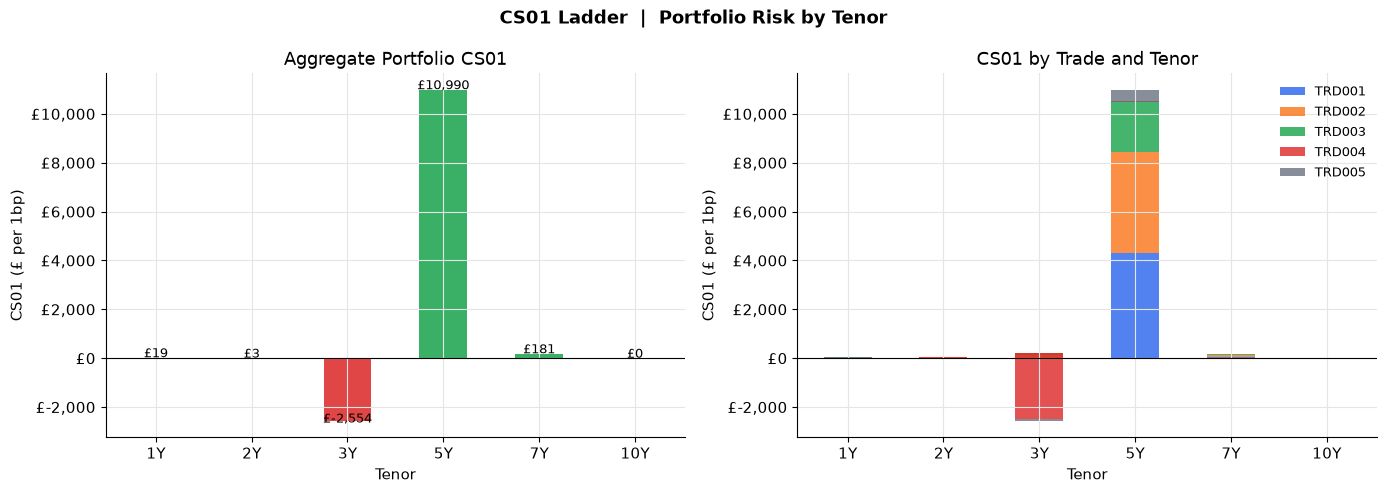

CS01 Ladder (aggregate):
  1Y: £19
  2Y: £3
  3Y: £-2,554
  5Y: £10,990
  7Y: £181
  10Y: £0
  Total: £8,639


In [4]:
ladder = defaultdict(float)
for p in portfolio:
    for tenor, c01 in p['cs01_tenor'].items():
        ladder[tenor] += c01

tenors  = sorted(ladder.keys())
values  = [ladder[t] for t in tenors]
labels  = [f'{int(t)}Y' for t in tenors]
colours = [GREEN if v >= 0 else RED for v in values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CS01 Ladder  |  Portfolio Risk by Tenor', fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.bar(labels, values, color=colours, alpha=0.85, width=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Aggregate Portfolio CS01')
ax.set_xlabel('Tenor')
ax.set_ylabel('CS01 (£ per 1bp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, values):
    ypos = bar.get_height() + 20 if val >= 0 else bar.get_height() - 80
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'£{val:,.0f}', ha='center', fontsize=9)

ax = axes[1]
trade_colours = [BLUE, ORANGE, GREEN, RED, GREY]
bottom = np.zeros(len(tenors))
for i, p in enumerate(portfolio):
    vals = [p['cs01_tenor'].get(t, 0) for t in tenors]
    ax.bar(labels, vals, bottom=bottom, label=p['id'],
           color=trade_colours[i % len(trade_colours)], alpha=0.8, width=0.5)
    bottom += np.array(vals)

ax.axhline(0, color='black', lw=0.8)
ax.set_title('CS01 by Trade and Tenor')
ax.set_xlabel('Tenor')
ax.set_ylabel('CS01 (£ per 1bp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03a_cs01_ladder.png', dpi=150, bbox_inches='tight')
plt.show()

print('CS01 Ladder (aggregate):')
for t, v in zip(labels, values):
    print(f'  {t}: £{v:,.0f}')
print(f'  Total: £{sum(values):,.0f}')

---
## 3. Stress Test — Spread Scenarios

In [5]:
scenarios = {
    'Spreads -100bps': -100,
    'Spreads -50bps':   -50,
    'Spreads -25bps':   -25,
    'Base':               0,
    'Spreads +25bps':   +25,
    'Spreads +50bps':   +50,
    'Spreads +100bps': +100,
    'Spreads +200bps': +200,
}

def portfolio_pnl(bump_bps):
    total = 0.0
    for trade in trade_data:
        entity     = trade['entity']
        spread_crv = parse_spreads(entity)
        bumped_crv = {t: s + bump_bps for t, s in spread_crv.items()}
        t_date     = date.fromisoformat(trade['trade_date'])
        t_mat      = date.fromisoformat(trade['maturity'])
        rec        = trade['recovery_rate']
        pos        = 1 if trade['position'] == 'protection_buyer' else -1

        if any(s + bump_bps <= 0 for s in spread_crv.values()):
            continue

        dc_b  = DiscountCurve(swap_rates)
        sc_b  = SurvivalCurve(spread_crv, dc_b, recovery=rec, trade_date=t_date)
        sch_b = build_schedule(t_date, t_mat)
        uf_b  = upfront(sch_b, sc_b, dc_b, trade['coupon_bps'], trade['notional'], rec, pos)

        dc_s = DiscountCurve(swap_rates)
        sc_s = SurvivalCurve(bumped_crv, dc_s, recovery=rec, trade_date=t_date)
        uf_s = upfront(sch_b, sc_s, dc_s, trade['coupon_bps'], trade['notional'], rec, pos)

        total += uf_s - uf_b
    return total

print('Running stress scenarios...')
stress_results = {}
for name, bump in scenarios.items():
    pnl = portfolio_pnl(bump)
    stress_results[name] = pnl
    print(f'  {name:<22}: £{pnl:>10,.0f}')

Running stress scenarios...
  Spreads -100bps       : £  -738,477
  Spreads -50bps        : £  -361,834
  Spreads -25bps        : £  -218,504
  Base                  : £         0
  Spreads +25bps        : £   213,581
  Spreads +50bps        : £   422,354
  Spreads +100bps       : £   825,924
  Spreads +200bps       : £ 1,580,143


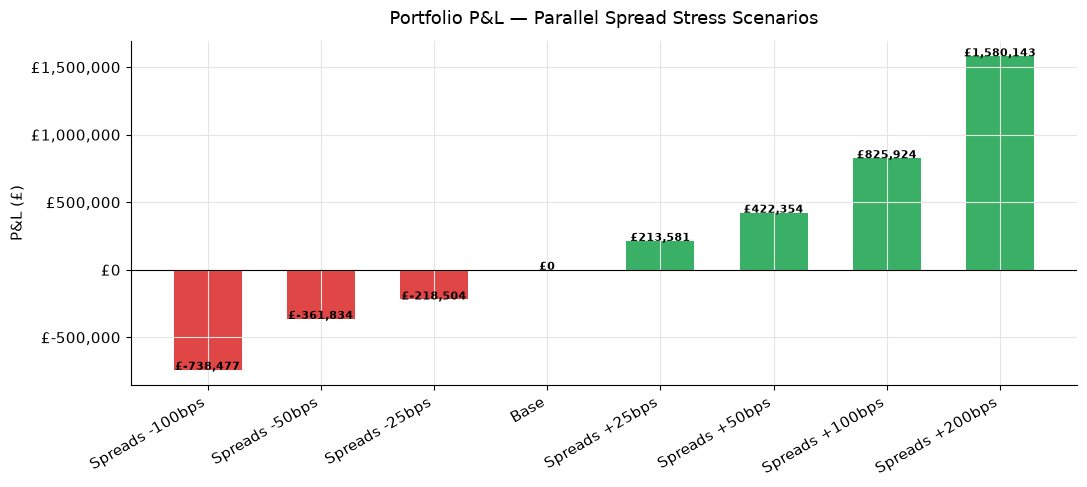

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

names   = list(stress_results.keys())
vals    = list(stress_results.values())
colours = [GREEN if v >= 0 else RED for v in vals]

bars = ax.bar(range(len(names)), vals, color=colours, alpha=0.85, width=0.6)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Portfolio P&L — Parallel Spread Stress Scenarios', pad=12)
ax.set_ylabel('P&L (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, vals):
    ypos = bar.get_height() + 200 if val >= 0 else bar.get_height() - 1500
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'£{val:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03b_stress_test.png', dpi=150, bbox_inches='tight')
plt.show()